## Вариант 7

Рассмотрим систему дифференциальных уравнений:
$$
\dot{x} = x(1 - x)-\frac{axy}{1+bx},
$$  
$$
\dot{y} = \frac{cxy}{1+bx}-y.
$$

**Цели работы**: 
- Провести линейный анализ устойчивости стационарных точек для двумерной системы обыкновенных дифференциальных нелинейных уравнений.
- Определить значения управляющих параметров, при которых происходит бифуркация Хопфа, построить фазовые портреты до и после бифуркации.
- Найти мультипликаторы Флоке для численного анализа устойчивости предельного цикла.

### Нахождение стационарных точек

Для стационарных точек решаем систему:
$$
f(x,y) = x(1 - x)-\frac{axy}{1+bx} = 0,
$$
$$
g(x, y) = \frac{cxy}{1+bx}-y = 0.
$$

In [90]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.integrate import solve_ivp

x, y = symbols('x y', real=True)
a, b, c = symbols('a b c')

eq1 = x*(1 - x) - (a*x*y)/(1+b*x)
eq2 = (c*x*y)/(1+b*x) - y

solutions = solve([eq1, eq2], [x, y])
solutions

[(0, 0), (1, 0), (-1/(b - c), -c*(b - c + 1)/(a*(b - c)**2))]

### Вычисление матрицы Якоби

Матрица Якоби:
$$
J =
\begin{pmatrix}
\frac{\partial f}{\partial x} & \frac{\partial f}{\partial y} \\
\frac{\partial g}{\partial x} & \frac{\partial g}{\partial y}
\end{pmatrix}.
$$


In [91]:
J = Matrix([[diff(eq1, x), diff(eq1, y)], [diff(eq2, x), diff(eq2, y)]])
J


Matrix([
[a*b*x*y/(b*x + 1)**2 - a*y/(b*x + 1) - 2*x + 1,    -a*x/(b*x + 1)],
[         -b*c*x*y/(b*x + 1)**2 + c*y/(b*x + 1), c*x/(b*x + 1) - 1]])

### Оценка матрицы Якоби в стационарной точке

1. Подставляем $x = 0$ и $y = 0$ в матрицу Якоби
2. Подставляем $x = 1$ и $y = 0$ в матрицу Якоби
3. Подставляем $x = -\frac1{b - c}$ и $y = -\frac{c(b - c + 1)}{a(b - c)^2}$ в матрицу Якоби

In [92]:
J_solutions = []
for i in range(len(solutions)):
    J_solutions.append(J.subs([(x, solutions[i][0]), (y, solutions[i][1])]))

In [93]:
for i, (sol, J_sol) in enumerate(zip(solutions, J_solutions)):
    print(f"Точка {i+1}: {sol}")
    display(J_sol)
    print()

Точка 1: (0, 0)


Matrix([
[1,  0],
[0, -1]])


Точка 2: (1, 0)


Matrix([
[-1,    -a/(b + 1)],
[ 0, c/(b + 1) - 1]])


Точка 3: (-1/(b - c), -c*(b - c + 1)/(a*(b - c)**2))


Matrix([
[b*c*(b - c + 1)/((b - c)**3*(-b/(b - c) + 1)**2) + c*(b - c + 1)/((b - c)**2*(-b/(b - c) + 1)) + 1 + 2/(b - c),      a/((b - c)*(-b/(b - c) + 1))],
[     -b*c**2*(b - c + 1)/(a*(b - c)**3*(-b/(b - c) + 1)**2) - c**2*(b - c + 1)/(a*(b - c)**2*(-b/(b - c) + 1)), -c/((b - c)*(-b/(b - c) + 1)) - 1]])

### Линейный анализ устойчивости стационарных точек

Для числовых (не символьных) матриц Якоби проверяем знак вещественной части собственных значений: если $\operatorname{Re}(\lambda_i) < 0$ для всех $i$, точка устойчива.

In [94]:
for i in range(len(J_solutions)):
    J0 = J_solutions[i]
    if J0.is_symbolic():
        print(f"Точка {i+1}: {solutions[i]} — зависит от параметров")
        continue
    
    is_stable = True
    for ev in J0.eigenvals():
        if re(ev) >= 0:
            is_stable = False
            break
    
    if is_stable:
        print(f"Точка {i+1}: {solutions[i]} — устойчива")
    else:
        print(f"Точка {i+1}: {solutions[i]} — неустойчива")


Точка 1: (0, 0) — неустойчива
Точка 2: (1, 0) — зависит от параметров
Точка 3: (-1/(b - c), -c*(b - c + 1)/(a*(b - c)**2)) — зависит от параметров


### Вычисление следа и определителя матрицы Якоби

След $\operatorname{Tr}(J)$ и определитель $\det(J)$ определяют тип особой точки. Для бифуркации Хопфа необходимо $\operatorname{Tr}(J) = 0$ при $\det(J) > 0$ — тогда собственные значения чисто мнимые.

In [95]:
Tr_solutions = []
for i in range(len(J_solutions)):
    Tr_solutions.append(J_solutions[i].trace())

Det_solutions = []
for i in range(len(J_solutions)):
    Det_solutions.append(J_solutions[i].det())

In [96]:
for i in range(len(solutions)):
    print(f"Точка {i+1}: {solutions[i]}")
    display(Eq(Symbol('Tr'), Tr_solutions[i]))
    display(Eq(Symbol('Det'), Det_solutions[i]))
    print()

Точка 1: (0, 0)


Eq(Tr, 0)

Eq(Det, -1)


Точка 2: (1, 0)


Eq(Tr, c/(b + 1) - 2)

Eq(Det, -c/(b + 1) + 1)


Точка 3: (-1/(b - c), -c*(b - c + 1)/(a*(b - c)**2))


Eq(Tr, b*c*(b - c + 1)/((b - c)**3*(-b/(b - c) + 1)**2) - c/((b - c)*(-b/(b - c) + 1)) + c*(b - c + 1)/((b - c)**2*(-b/(b - c) + 1)) + 2/(b - c))

Eq(Det, (-b + c - 1)/c)

### Проверка условий для бифуркации Хопфа

Бифуркация Хопфа возникает при выполнении двух условий одновременно:

$$\operatorname{Tr}(J) = 0, \qquad \det(J) > 0.$$

Из первого условия выразим критическое значение $c(b)$, затем подставим его во второе и проверим, при каких $b$ оно выполняется. Проверим каждую стационарную точку по очереди.

#### Точка 1: $(0,\; 0)$

Определитель матрицы Якоби в этой точке $\det(J) = -1 < 0$ при всех значениях параметров, поэтому условие бифуркации Хопфа заведомо не выполняется.

#### Точка 2

Решаем $\operatorname{Tr}(J) = 0$ относительно $c$ и подставляем результат в $\det(J) > 0$.

In [97]:
c_eq_2 = solve(Tr_solutions[1], c)[0]
c_eq_2

2*b + 2

In [98]:
ineq_2 = Det_solutions[1].subs([(c, c_eq_2)]) > 0
ineq_2

1 - (2*b + 2)/(b + 1) > 0

In [99]:
solve(ineq_2, b)

False

Неравенство $\det(J) > 0$ не имеет решений по $b$, поэтому вторая стационарная точка не допускает бифуркацию Хопфа.

#### Точка 3

Повторяем ту же процедуру: из $\operatorname{Tr}(J) = 0$ находим $c(b)$, затем проверяем $\det(J) > 0$.

In [100]:
c_eq_3 = solve(Tr_solutions[2], c)[0]
c_eq_3

(b**2 + b)/(b - 1)

In [101]:
ineq_3 = Det_solutions[2].subs([(c, c_eq_3)]) > 0
ineq_3

(b - 1)*(-b - 1 + (b**2 + b)/(b - 1))/(b**2 + b) > 0

In [102]:
solve(ineq_3, b)

(0 < b) & (b < oo)

**Вывод.** Бифуркация Хопфа возможна только в третьей стационарной точке и только при $b > 0$. Критическое значение параметра задаётся кривой

$$c^*(b) = \frac{b^2 + b}{b - 1}, \qquad b > 0,\; b \neq 1.$$

### Построим фазовые портреты до и после бифуркации

Фиксируем $a = 1$ и используем $b$ как управляющий параметр. Значение $c$ определяем из кривой Хопфа $c^*(b)$ для третьей стационарной точки. Рассматриваем два режима:

- **до бифуркации:** $b = -1/2$ (не входит в область $b > 0$, бифуркация Хопфа отсутствует);
- **на бифуркации:** $b = 1/2$ (собственные значения чисто мнимые).

Для каждого случая подставляем параметры в исходную систему, получаем числовые правые части через `lambdify` и интегрируем методом Эйлера на сетке начальных условий.

In [103]:
nbif_sub = {a: 1, b: -Rational(1, 2)}
bif_sub = {a: 1, b: Rational(1, 2)}
nbif_sub[c] = c_eq_3.subs([(b, nbif_sub[b])])
bif_sub[c] = c_eq_3.subs([(b, bif_sub[b])])

#### До бифуркации ($b = -1/2$)

Подставляем параметры и выводим явный вид правых частей системы, затем интегрируем на сетке $[-3, 3]^2$.

In [104]:
def euler_grid(dxdt, dydt, X, Y, T_end, time_step):
    t = np.arange(0, T_end, time_step)
    result = np.zeros((len(t) + 1, 2, *X.shape))
    result[0, 0], result[0, 1] = X, Y
    X_cur, Y_cur = X.copy(), Y.copy()
    for i, _ in enumerate(tqdm(t)):
        X_cur += dxdt(X_cur, Y_cur) * time_step
        Y_cur += dydt(X_cur, Y_cur) * time_step
        result[i + 1, 0] = X_cur
        result[i + 1, 1] = Y_cur
    return result

time_step = 0.01
T_end = 100
h = 0.5
X, Y = np.meshgrid(np.arange(-3, 3, h), np.arange(-3, 3, h))

In [105]:
display(Eq(Symbol('dx/dt'), eq1.subs(nbif_sub).simplify()))
display(Eq(Symbol('dy/dt'), eq2.subs(nbif_sub).simplify()))

Eq(dx/dt, x*(2*y - (x - 2)*(x - 1))/(x - 2))

Eq(dy/dt, 2*y*(3 - 2*x)/(3*(x - 2)))

In [106]:
dxdt_nbif = lambdify((x, y), eq1.subs(nbif_sub).simplify(), 'numpy')
dydt_nbif = lambdify((x, y), eq2.subs(nbif_sub).simplify(), 'numpy')
nbif_phase_portrait = euler_grid(dxdt_nbif, dydt_nbif, X, Y, T_end, time_step)

  0%|          | 0/10000 [00:00<?, ?it/s]<lambdifygenerated-9>:2: RuntimeWarning: divide by zero encountered in divide
  return x*(2*y - (x - 2)*(x - 1))/(x - 2)
<lambdifygenerated-9>:2: RuntimeWarning: invalid value encountered in divide
  return x*(2*y - (x - 2)*(x - 1))/(x - 2)
<lambdifygenerated-10>:2: RuntimeWarning: invalid value encountered in divide
  return (2/3)*y*(3 - 2*x)/(x - 2)
<lambdifygenerated-9>:2: RuntimeWarning: overflow encountered in multiply
  return x*(2*y - (x - 2)*(x - 1))/(x - 2)
<lambdifygenerated-10>:2: RuntimeWarning: invalid value encountered in multiply
  return (2/3)*y*(3 - 2*x)/(x - 2)
100%|██████████| 10000/10000 [00:00<00:00, 70469.17it/s]


#### На бифуркации ($b = 1/2$)

Аналогично подставляем параметры бифуркационного режима и интегрируем на той же сетке.

In [107]:
display(Eq(Symbol('dx/dt'), eq1.subs(bif_sub).simplify()))
display(Eq(Symbol('dy/dt'), eq2.subs(bif_sub).simplify()))

Eq(dx/dt, x*(-x**2 - x - 2*y + 2)/(x + 2))

Eq(dy/dt, 2*y*(-2*x - 1)/(x + 2))

In [108]:
dxdt = lambdify((x, y), eq1.subs(bif_sub).simplify(), 'numpy')
dydt = lambdify((x, y), eq2.subs(bif_sub).simplify(), 'numpy')
bif_phase_portrait = euler_grid(dxdt, dydt, X, Y, T_end, time_step)

  0%|          | 0/10000 [00:00<?, ?it/s]<lambdifygenerated-11>:2: RuntimeWarning: divide by zero encountered in divide
  return x*(-x**2 - x - 2*y + 2)/(x + 2)
<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in divide
  return x*(-x**2 - x - 2*y + 2)/(x + 2)
<lambdifygenerated-12>:2: RuntimeWarning: invalid value encountered in divide
  return 2*y*(-2*x - 1)/(x + 2)
<lambdifygenerated-11>:2: RuntimeWarning: invalid value encountered in subtract
  return x*(-x**2 - x - 2*y + 2)/(x + 2)
<lambdifygenerated-11>:2: RuntimeWarning: overflow encountered in multiply
  return x*(-x**2 - x - 2*y + 2)/(x + 2)
<lambdifygenerated-11>:2: RuntimeWarning: overflow encountered in square
  return x*(-x**2 - x - 2*y + 2)/(x + 2)
<lambdifygenerated-12>:2: RuntimeWarning: invalid value encountered in multiply
  return 2*y*(-2*x - 1)/(x + 2)
100%|██████████| 10000/10000 [00:00<00:00, 68352.33it/s]


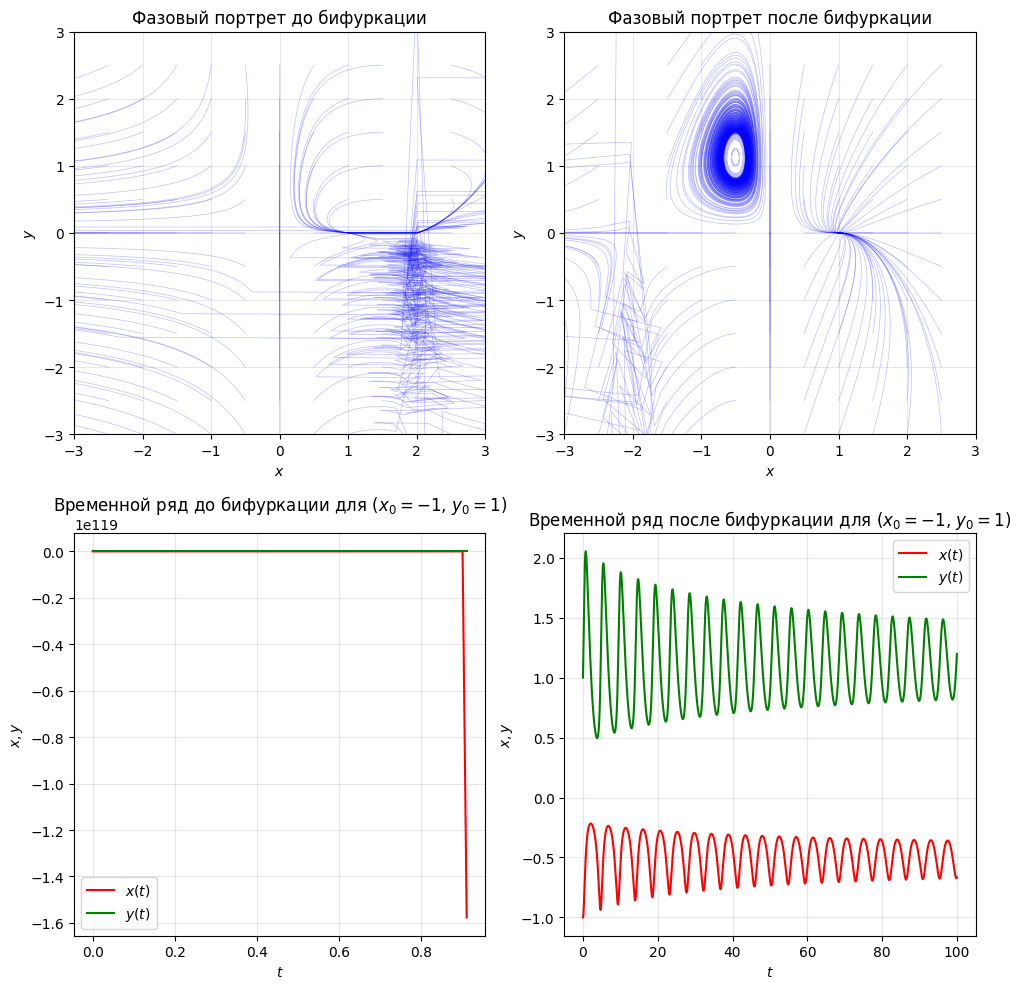

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
nbif_shape = nbif_phase_portrait.shape
t = np.linspace(0, T_end, nbif_shape[0])

# Top-left: Continuous phase portrait (many thin trajectories)
for x in range(nbif_shape[2]):
    for y in range(nbif_shape[3]):
        axes[0, 0].plot(nbif_phase_portrait[:, 0, x, y], nbif_phase_portrait[:, 1, x, y], 
                        'b-', alpha=0.25, linewidth=0.5)

# Bottom-left: Discrete phase portrait
for x in range(nbif_shape[2]):
    for y in range(nbif_shape[3]):
        axes[0, 1].plot(bif_phase_portrait[:, 0, x, y], bif_phase_portrait[:, 1, x, y], 
                        'b-', alpha=0.25, linewidth=0.5)

point = [-1, 1]
mid_x = int(abs((-3 + (point[0])) / 0.5))
mid_y = int(abs((-3 + (point[1])) / 0.5))

axes[1, 0].plot(t, nbif_phase_portrait[:, 0, mid_x, mid_y], 'r-', linewidth=1.5, label='$x(t)$')
axes[1, 0].plot(t, nbif_phase_portrait[:, 1, mid_x, mid_y], 'g-', linewidth=1.5, label='$y(t)$')
axes[1, 0].legend()

axes[1, 1].plot(t, bif_phase_portrait[:, 0, mid_x, mid_y], 'r-', linewidth=1.5, label='$x(t)$')
axes[1, 1].plot(t, bif_phase_portrait[:, 1, mid_x, mid_y], 'g-', linewidth=1.5, label='$y(t)$')
axes[1, 1].legend()


# Style matching image: limits, labels, titles, grids
for ax, title in zip([axes[0,0], axes[0,1]], ['Фазовый портрет до бифуркации', 'Фазовый портрет после бифуркации']):
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[1, 0].set_title(f'Временной ряд до бифуркации для ($x_0={point[0]}$, $y_0={point[1]}$)')
axes[1, 0].set_xlabel('$t$')
axes[1, 0].set_ylabel('$x, y$')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title(f'Временной ряд после бифуркации для ($x_0={point[0]}$, $y_0={point[1]}$)')
axes[1, 1].set_xlabel('$t$')
axes[1, 1].set_ylabel('$x, y$')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Сравнение фазовых портретов (сетка траекторий) и временных рядов $x(t)$, $y(t)$ для выбранной начальной точки — до и после бифуркации.

### Период предельного цикла

На бифуркации собственные значения матрицы Якоби в третьей стационарной точке чисто мнимые: $\lambda = \pm i\omega$. Период малых колебаний вблизи равновесия равен

$$T = \frac{2\pi}{|\operatorname{Im}(\lambda)|}.$$

Далее: находим собственные значения при параметрах бифуркации, по ним вычисляем $T$, затем численно интегрируем траекторию от точки, близкой к равновесию, на один период $T$, чтобы визуализировать предельный цикл.

#### Собственные значения

Собственные значения матрицы Якоби в третьей стационарной точке при параметрах бифуркации; ожидаем пару $\pm i\omega$.

In [110]:
# Собственные значения J в третьей точке при bif_sub — пара ±iω
eigenvals = list(J_solutions[2].eigenvals().keys())
display(eigenvals[0].subs(bif_sub))
display(eigenvals[1].subs(bif_sub))

sqrt(2)*I

-sqrt(2)*I

#### Период малых колебаний

$T = 2\pi / \omega$ по мнимой части собственного значения.

In [111]:
T = 2 * pi / abs(im(eigenvals[1].subs(bif_sub)))
T

sqrt(2)*pi

#### Траектория за один период

Интегрируем от точки $(x_0, y_0)$ вблизи третьей стационарной точки на время $T$ и строим предельный цикл.

  0%|          | 0/444289 [00:00<?, ?it/s]

100%|██████████| 444289/444289 [00:00<00:00, 983311.85it/s]


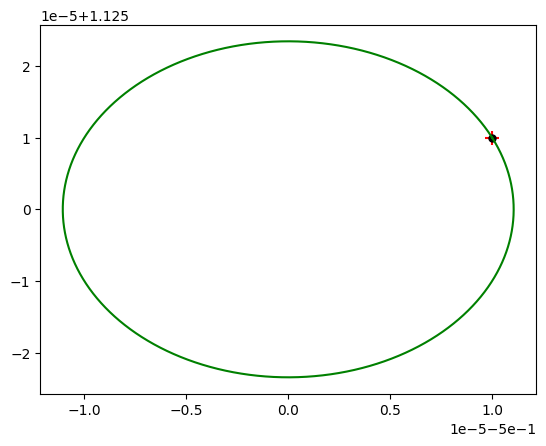

In [112]:
T_end = T
eps = 1e-5
time_step = 1e-5

t = np.arange(0, T_end + time_step, time_step)
x, y = float(solutions[2][0].subs(bif_sub)) + eps, float(solutions[2][1].subs(bif_sub)) + eps

cycle = np.zeros((len(t), 2))
cycle[0] = [x, y]

for i, _ in enumerate(tqdm(t[:-1])):
    x += dxdt(x, y) * time_step
    y += dydt(x, y) * time_step
    cycle[i + 1] = [x, y]

plt.scatter(cycle[0, 0], cycle[0, 1], c='red', s=100, marker='+', label='start point')
plt.scatter(cycle[-1, 0], cycle[-1, 1], c='black', s=100, marker='.', label='end point')
plt.plot(cycle[:, 0], cycle[:, 1], 'g-', linewidth=1.5)

plt.show()

### Мультипликаторы Флоке

Матрица монодромии — фундаментальная матрица линеаризованной системы, вычисленная вдоль предельного цикла за период $T$. Её собственные значения (мультипликаторы Флоке) определяют устойчивость цикла: если $|\mu_i| < 1$ для всех $i$, цикл устойчив.

Чтобы получить мультипликаторы, нужно вычислить матрицу монодромии $\Phi(T)$ — фундаментальную матрицу линеаризованной системы $\dot\Phi = J(x(t),y(t))\,\Phi$ вдоль предельного цикла. Ниже: явный вид Якобиана при параметрах бифуркации, численная функция $J(x,y)$, расширенная система (траектория + $\Phi$), интегрирование на один период $T$ и собственные значения $\Phi(T)$.

#### Матрица Якоби

Символьный вид $J$ при параметрах бифуркации и численная функция $J(x,y)$ для интегрирования вдоль цикла.

In [113]:
simplify(J.subs(bif_sub))

Matrix([
[-2*x - 4*y/(x + 2)**2 + 1,         -2*x/(x + 2)],
[          -6*y/(x + 2)**2, 2*(-2*x - 1)/(x + 2)]])

In [114]:
def J_function(x, y):
    J11 = -2*x - 4*y/(x+2)**2 + 1
    J12 = -(2 * x) / (x + 2)
    J21 = -(6 * y) / (x + 2)**2
    J22 = 2*(-2*x - 1) / (x + 2)
    return np.array([[J11, J12], [J21, J22]])

#### Расширенная система и матрица монодромии

Расширенная система: траектория $(x,y)$ и матрица $\Phi$ с уравнением $\dot\Phi = J\,\Phi$. Начало — точка на цикле (конец траектории из предыдущей секции), $\Phi(0) = I$. Интегрируем на $[0, T]$ и получаем $\Phi(T)$.

In [115]:
def combined_system(t, Z):
    x, y = Z[0], Z[1]
    Phi = Z[2:].reshape((2, 2))
    dx = dxdt(x, y)
    dy = dydt(x, y)
    J = J_function(x, y)
    dPhi = J @ Phi
    return np.concatenate(([dx, dy], dPhi.flatten()))

x0, y0 = cycle[-1, 0], cycle[-1, 1]
Phi_0 = np.eye(2).flatten()
Z0 = np.concatenate(([x0, y0], Phi_0))

T_exact = float(T)

sol = solve_ivp(
    fun=combined_system,
    t_span=[0, T_exact],
    y0=Z0,
    method='RK45',
    rtol=1e-8,
    atol=1e-8,
)

Phi_T = sol.y[2:, -1].reshape((2, 2))


#### Мультипликаторы Флоке

Собственные значения матрицы монодромии $\Phi(T)$; для устойчивого цикла на бифуркации один мультипликатор равен 1.

In [116]:
multipliers = np.linalg.eigvals(Phi_T)
print("Матрица монодромии Phi(T):")
print(Phi_T)
print("\nМультипликаторы Флоке:")
for i, mu in enumerate(multipliers):
    print(f"mu_{i+1} = {mu.real:.6f} {'+' if mu.imag >= 0 else '-'} {abs(mu.imag):.2e}*j")

Матрица монодромии Phi(T):
[[ 9.99999971e-01  2.40869447e-09]
 [-1.02713614e-08  9.99999971e-01]]

Мультипликаторы Флоке:
mu_1 = 1.000000 + 4.96e-09*j
mu_2 = 1.000000 - 4.96e-09*j
